# GRU Neural Network for Insurance Claims Reserving

This notebook implements Recurrent Neural Networks (RNN, LSTM, GRU) and a Feed-Forward Neural Network (FFNN) for predicting ultimate insurance claim amounts.

## Overview
- **Objective**: Predict ultimate paid claim amounts using sequential payment history
- **Models**: Basic LogLink Feed-Forward NN, RNN, LSTM and GRU
- **Train/Test splits**: Supports both rectangular and calendar period (time-based) splits
- **Error term**: MSE (alternative loss functions can be configured)
- **Logging**: TensorBoard integration for training diagnostics


In [117]:
import pandas as pd
import numpy as np
import time
from matplotlib import pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn.utils.rnn import pad_sequence
from torch.utils.tensorboard import SummaryWriter

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin, TransformerMixin
from sklearn.utils.validation import check_is_fitted, check_consistent_length

from utils.excel import save_df_to_excel
from utils.pipeline_transforms import ColumnKeeper, Make3D


In [118]:
# Verify installed package versions if needed:
# import pkg_resources
# for pkg in ['pandas', 'numpy', 'scikit-learn', 'tensorboard', 'torch']:
#     print(pkg, pkg_resources.get_distribution(pkg).version)


In [119]:
# --- Experiment parameters ---
cutoff = 40    # Calendar period cut-off for the test set
cutoff1 = 32   # Calendar period cut-off for the training set

# Training iterations: 100 for quick experiments, 500+ for convergence
nn_iter = 2001


In [120]:
pd.options.display.float_format = '{:,.2f}'.format

# Create timestamp for logging
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_filename = f"log_GRU_outputs_{timestamp}.xlsx"

# Initialise TensorBoard writer — logs go to ./runs/ by default
writer = SummaryWriter()


## TensorBoard Setup

TensorBoard is used for logging training diagnostics and visualisations. Ensure it is installed:

```
pip install tensorboard
```

To launch TensorBoard after running this notebook, open a terminal in the project root directory and run:

```
tensorboard --logdir=runs
```

Then navigate to `http://localhost:6006/` in your browser.

More info: https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html


## Data Loading and Processing

We load the raw insurance claims data from a CSV file and engineer the features required for training.
This includes setting up payment period cut-offs, settlement flags, and cumulative payment indicators.


In [121]:
# Update dirname to point to the 01_data folder relative to the notebook location
dirname = "../01_data/"
filename = "data_origframework_nofills_nosttl.csv"

dat = pd.read_csv(dirname + filename)
print(f"Data loaded: {dat.shape[0]:,} rows, {dat.shape[1]} columns")

save_df_to_excel(dat, df_name="Original Data", filename=log_filename, mode='w')


Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'Original Data'


### Set up Train and Test Sets

Two approaches to splitting the data are supported:
- `train_ind`: rectangular split (all claims up to a fixed development period)
- `train_ind_time`: calendar period split — the cut-off `cutoff1` is configured at the top of the notebook

The active split is controlled by the filter conditions applied in the cell below.


In [122]:
# Preview the loaded data
print(f"Shape: {dat.shape}")
dat.head()


,Unnamed: 0.1,Unnamed: 0,claim_no,pmt_no,occurrence_period,occurrence_time,claim_size,notidel,setldel,payment_time,...,payment_delay,noti_period,settle_period,development_period,is_settled,payment_size_cumulative,log1_paid_cumulative,train_ind,train_ind_time,cv_ind
0,0,1,1,1,1,0.73,"232,310.09",0.66,23.21,5.33,...,3.93,2,25,5,False,"13,226.34",9.49,False,True,1
1,1,2,1,2,1,0.73,"232,310.09",0.66,23.21,10.09,...,4.76,2,25,10,False,"28,912.20",10.27,False,True,1
2,2,3,1,3,1,0.73,"232,310.09",0.66,23.21,18.02,...,7.93,2,25,18,False,"43,555.48",10.68,False,True,4
3,3,4,1,4,1,0.73,"232,310.09",0.66,23.21,22.82,...,4.79,2,25,22,False,"213,597.38",12.27,False,True,3
4,5,6,2,1,1,0.33,"237,675.12",0.74,22.15,3.46,...,2.38,2,24,3,False,"14,014.05",9.55,False,True,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15257,19316,19317,3663,1,40,39.87,"40,653.72",2.29,10.67,44.56,...,2.40,43,53,5,False,"2,618.23",7.87,False,False,0
15258,19317,19318,3663,2,40,39.87,"40,653.72",2.29,10.67,46.40,...,1.84,43,53,7,False,"4,832.11",8.48,False,False,2
15259,19318,19319,3663,3,40,39.87,"40,653.72",2.29,10.67,48.45,...,2.06,43,53,9,False,"7,124.86",8.87,False,False,4
15260,19319,19320,3663,4,40,39.87,"40,653.72",2.29,10.67,50.24,...,1.78,43,53,11,False,"9,492.18",9.16,False,False,1


In [123]:
# --- Time-based split flags ---
dat["train_ind_time"] = (dat.payment_period <= cutoff1)   # True for records in the training window
dat["test_ind_time"]  = (dat.payment_period <= cutoff)    # True for records in the full evaluation window
dat["train_settled"]  = (dat.settle_period <= cutoff)     # Settled within the evaluation window
dat["settled_flag"]   = (dat.settle_period <= cutoff1)    # Settled within the training window

# --- Settlement status ---
dat['is_settled'] = dat['is_settled'].astype(int)
dat["is_settled_future"] = dat.is_settled.copy()
dat.loc[dat['payment_period'] > cutoff, 'is_settled_future'] = -1   # Flag future periods
dat["future_flag"] = ~dat["train_ind_time"]

# --- Cumulative payment (masked for future periods) ---
dat["future_paid_cum"] = dat.log1_paid_cumulative.copy()
dat.loc[dat['payment_period'] > cutoff, 'future_paid_cum'] = 12.3   # Placeholder for unknown future payments

# --- Large loss indicator ---
dat["L250k"] = (dat['claim_size'] > 250000).astype(int)

# --- Snapshot values at the evaluation cut-off date ---
currentdev   = dat[dat['payment_period'] == cutoff].set_index('claim_no')['development_period'].to_dict()
currentpaid  = dat[dat['payment_period'] == cutoff].set_index('claim_no')['log1_paid_cumulative'].to_dict()
currentpmtno = dat[dat['payment_period'] == cutoff].set_index('claim_no')['pmt_no'].to_dict()

dat['curr_dev']   = dat['claim_no'].map(currentdev).fillna(0)
dat['curr_paid']  = dat['claim_no'].map(currentpaid).fillna(0)
dat['curr_pmtno'] = dat['claim_no'].map(currentpmtno).fillna(0)

save_df_to_excel(dat, df_name="Processed Data", filename=log_filename, mode='a')


<positron-console-cell-123>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<positron-console-cell-123>:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df

Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'Processed Data'


### Feature Selection

Define the input features and target variable. Commented-out features can be re-enabled to experiment with alternative model specifications.


In [124]:
# Active features — comment/uncomment to experiment with alternative specifications
features = [
    "occurrence_time",
    "notidel",
    "development_period",
    "pmt_no",
    "log1_paid_cumulative",
    # "initial_case_estimate",
    # "settled_flag",
    # "is_settled",
]

data_cols = features + ["claim_no"]
youtput = "claim_size"


### Define Train and Test Datasets

The active split (S3) uses a calendar period cut-off: training on settled claims within `cutoff1`, testing on unsettled claims up to `cutoff`.
Alternative splits (rectangular, S0, S6) are shown commented-out below for reference.


In [125]:
# --- Active split: S3 (calendar period, settled claims only) ---
# Training: settled claims with payment history within the training window
trainx = dat.loc[
    (dat.train_ind_time == 1) & (dat.train_ind == 1) & (dat.train_settled == 1),
    features + ["claim_no"]
]
y_train = (
    dat.loc[(dat.train_ind_time == 1) & (dat.train_ind == 1) & (dat.train_settled == 1)]
    .groupby('claim_no')[youtput].last()
)

# Test: unsettled claims in the evaluation window (held-out occurrence years)
testx = dat.loc[
    (dat.test_ind_time == 1) & (dat.train_ind == 0) & (dat.train_settled == 0),
    features + ["claim_no"]
]
y_test = (
    dat.loc[(dat.train_ind_time == 1) & (dat.train_ind == 0) & (dat.train_settled == 0)]
    .groupby('claim_no')[youtput].last()
)

# --- Alternative: rectangular split (all claims up to a fixed development period) ---
# trainx = dat.loc[dat.train_ind == 1, features + ["claim_no"]]
# y_train = dat.loc[dat.train_ind == 1].groupby('claim_no')[youtput].last()
# testx  = dat.loc[dat.train_ind == 0, features + ["claim_no"]]
# y_test  = dat.loc[dat.train_ind == 0].groupby('claim_no')[youtput].last()

save_df_to_excel(trainx, df_name="x_train", filename=log_filename, mode='a')
save_df_to_excel(y_train, df_name="y_train", filename=log_filename, mode='a')
save_df_to_excel(testx,  df_name="x_test",  filename=log_filename, mode='a')
save_df_to_excel(y_test,  df_name="y_test",  filename=log_filename, mode='a')


Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'x_train'
Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'y_train'
Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'x_test'
Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'y_test'


,occurrence_time,notidel,development_period,pmt_no,log1_paid_cumulative,claim_size,claim_no
0,0.73,0.66,5,1,9.49,"232,310.09",1
1,0.73,0.66,10,2,10.27,"232,310.09",1
2,0.73,0.66,18,3,10.68,"232,310.09",1
3,0.73,0.66,22,4,12.27,"232,310.09",1
4,0.33,0.74,3,1,9.55,"237,675.12",2
...,...,...,...,...,...,...,...
15257,39.87,2.29,5,1,7.87,"40,653.72",3663
15258,39.87,2.29,7,2,8.48,"40,653.72",3663
15259,39.87,2.29,9,3,8.87,"40,653.72",3663
15260,39.87,2.29,11,4,9.16,"40,653.72",3663


In [126]:
# Preview the training dataset
print(f"Training set: {trainx['claim_no'].nunique():,} claims, {len(trainx):,} transactions")
trainx.head()


,occurrence_time,notidel,development_period,pmt_no,log1_paid_cumulative,claim_no
13,0.74,0.42,2,1,9.20,4
14,0.74,0.42,7,2,10.04,4
15,0.74,0.42,12,3,10.45,4
16,0.74,0.42,17,4,12.27,4
17,0.62,1.64,4,1,8.68,5
...,...,...,...,...,...,...
11524,29.69,0.05,2,1,8.23,2776
11576,29.12,0.51,1,1,8.08,2787
11577,29.78,1.00,2,1,8.25,2788
11601,29.99,0.91,2,1,7.64,2794


In [127]:
# Preview the test dataset
print(f"Test set: {testx['claim_no'].nunique():,} claims, {len(testx):,} transactions")
testx.head()


,occurrence_time,notidel,development_period,pmt_no,log1_paid_cumulative,claim_no
4219,10.27,0.88,4,1,10.11,1000
4220,10.27,0.88,12,2,10.81,1000
4221,10.27,0.88,19,3,11.15,1000
4222,10.27,0.88,22,4,11.46,1000
4223,10.27,0.88,29,5,14.07,1000
...,...,...,...,...,...,...
14567,38.45,0.26,1,1,8.44,3500
14581,39.00,0.44,1,1,8.49,3503
14607,38.30,0.59,1,1,8.26,3511
14698,38.12,0.28,1,1,8.09,3533


In [128]:
# Payment triangle for the test set — used to sense-check the data splits
triangle = (
    dat.loc[(dat.test_ind_time == 1) & (dat.train_ind == 0) & (dat.train_settled == 0)]
    .groupby(["occurrence_period", "development_period", "payment_period"], as_index=False)
    .agg({"payment_size_cumulative": "sum", "payment_size": "sum"})
    .sort_values(by=["occurrence_period", "development_period"])
)

triangle.pivot(index="occurrence_period", columns="development_period", values="payment_size_cumulative")


development_period,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,27,29
occurrence_period,,,,,,,,,,,,,,,,,,,,,
11,NaN,NaN,NaN,NaN,"24,587.95",NaN,NaN,NaN,NaN,NaN,...,NaN,"69,346.74",NaN,NaN,"94,674.77",NaN,NaN,NaN,NaN,"1,288,355.53"
13,NaN,NaN,NaN,NaN,NaN,NaN,"12,744.58",NaN,NaN,"22,881.54",...,"46,063.29",NaN,NaN,NaN,NaN,"55,638.53",NaN,NaN,"66,141.45",NaN
14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"9,915.40",NaN,NaN,...,"39,199.43",NaN,NaN,NaN,"47,944.76",NaN,NaN,NaN,NaN,NaN
15,NaN,NaN,NaN,NaN,NaN,"12,202.07","22,004.96","22,984.67","7,090.50",NaN,...,"61,616.72","80,491.69","39,552.49","46,558.58","60,825.27",NaN,"414,134.91","335,138.00",NaN,NaN
16,NaN,NaN,NaN,NaN,"27,308.11","11,044.91","23,738.50","79,123.21","33,522.87","32,103.84",...,"81,375.27","76,313.64",NaN,"46,350.59","145,481.96","137,608.09","97,713.01",NaN,NaN,NaN
17,NaN,NaN,NaN,NaN,NaN,"21,024.05",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"245,722.98",NaN,NaN,NaN,NaN
18,NaN,NaN,NaN,NaN,"15,470.45","10,205.60",NaN,"23,942.79","22,562.65",NaN,...,NaN,"77,776.17","73,653.10","47,291.86",NaN,NaN,NaN,NaN,NaN,NaN
19,NaN,NaN,"6,791.45",NaN,"13,984.95","36,024.95",NaN,NaN,"46,337.03","14,953.19",...,"35,980.80","88,944.69",NaN,"634,267.49",NaN,NaN,NaN,NaN,NaN,NaN
20,NaN,NaN,"7,017.77","35,501.95",NaN,"38,073.51","52,181.00","85,476.78","42,040.99","34,445.61",...,"129,356.73","50,700.82","286,844.14",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [129]:
nclms = trainx['claim_no'].nunique()
nfeatures = len(features)
print(f"Training claims: {nclms:,}")
print(f"Number of features: {nfeatures} — {features}")


True 1298
5


### Prepare 3D Tensor Input for RNN

RNN-based models (GRU, LSTM, RNN) require input in 3D tensor form: `(batch_size, sequence_length, n_features)`.
This transformation is handled automatically within the pipeline by the `Make3D` transformer.


In [130]:
class TabularNetRegressor(BaseEstimator, RegressorMixin):
    def __init__(
        self, 
        module,
        criterion=nn.MSELoss(),
        max_iter=100,
        max_lr=0.01,
        keep_best_model=False,
        batch_function=None,
        rebatch_every_iter=1,
        n_input=nfeatures,
        n_hidden=20,
        n_output=1,
        l1_penalty=0.0,          # lambda is a reserved word in Python
        l1_applies_params=["linear.weight", "hidden.weight"],
        weight_decay=0.0,
        batch_norm=False,
        interactions=False,
        dropout=0.0,
        clip_value=None,
        n_gaussians=3,
        verbose=1,
        device="cpu",
        init_bias=None,
        **kwargs
    ):
        """Tabular Neural Network Regressor for Claims Reserving.

        Wraps a PyTorch nn.Module in a scikit-learn compatible interface.
        Supports MSE loss, log-link, L1/L2 regularisation, and early stopping.

        Args:
            module: PyTorch nn.Module class. Must accept n_input, n_output, n_hidden,
                batch_norm, dropout, and init_bias as constructor arguments.
            criterion: PyTorch loss function (default: nn.MSELoss).
            max_iter (int): Maximum training epochs.
            max_lr (float): Peak learning rate for the OneCycleLR scheduler.
            keep_best_model (bool): If True, restore the weights with the lowest training loss
                at the end of training. Note: this tracks training loss, not validation loss,
                so it does not provide true early stopping against overfitting.
            batch_function (callable or None): Optional function to draw a mini-batch
                from X and y tensors each epoch.
            rebatch_every_iter (int): How often to refresh the mini-batch.
            l1_penalty (float): L1 (LASSO) regularisation strength.
            l1_applies_params (list[str]): Named parameters to apply L1 penalty to.
            weight_decay (float): L2 regularisation strength (applied via AdamW).
            clip_value (float or None): Gradient norm clipping threshold.
            n_hidden (int): Hidden layer width.
            batch_norm (bool): Whether to use batch normalisation.
            dropout (float): Dropout rate.
            init_bias: Initial output bias. Defaults to log(mean(y)) if None.
            verbose (int): Logging verbosity (0 = silent, 1 = print progress).
        """
        self.module = module
        self.criterion = criterion
        self.keep_best_model = keep_best_model
        self.l1_penalty = l1_penalty
        self.l1_applies_params = l1_applies_params
        self.weight_decay = weight_decay
        self.max_iter = max_iter
        self.n_hidden = n_hidden
        self.batch_norm = batch_norm
        self.batch_function = batch_function
        self.rebatch_every_iter = rebatch_every_iter
        self.interactions = interactions
        self.dropout = dropout
        self.n_gaussians = n_gaussians
        self.device = device
        self.target_device = torch.device(device)
        self.max_lr = max_lr
        self.init_bias = init_bias
        self.print_loss_every_iter = max(1, int(max_iter / 10))
        self.verbose = verbose
        self.clip_value = clip_value
        self.kwargs = kwargs


    def fix_array(self, y):
        """Ensure y is a 2D float32 numpy array."""
        if isinstance(y, (pd.DataFrame, pd.Series)):
            y = y.values
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        return y.astype(np.float32)


    def setup_module(self, n_input, n_output):
        """Instantiate and move the neural network module to the target device."""
        self.module_ = self.module(
            n_input=n_input,
            n_output=n_output,
            n_hidden=self.n_hidden,
            batch_norm=self.batch_norm,
            dropout=self.dropout,
            init_bias=self.init_bias_calc if self.init_bias is None else self.init_bias,
            **self.kwargs
        ).to(self.target_device)


    def fit(self, X, y):
        """Initialise and train the model."""
        n_input = X.shape[-1]
        n_output = 1 if y.ndim == 1 else y.shape[-1]
        self.init_bias_calc = np.log(y.mean()).astype(np.float32)
        self.setup_module(n_input=n_input, n_output=n_output)
        self.partial_fit(X, y)
        return self


    def partial_fit(self, X, y):
        """Run the training loop, updating an existing model if already fitted."""
        check_consistent_length(X, y)

        X_tensor = X.to(self.target_device)
        y_tensor = torch.from_numpy(self.fix_array(y)).to(self.target_device)

        # AdamW optimizer with OneCycleLR scheduler
        optimizer = torch.optim.AdamW(
            params=self.module_.parameters(),
            lr=self.max_lr / 10,
            weight_decay=self.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=self.max_lr,
            steps_per_epoch=1,
            epochs=self.max_iter
        )

        # Instantiate loss function
        try:
            loss_fn = self.criterion(log_input=False).to(self.target_device)
        except TypeError:
            loss_fn = self.criterion

        best_loss = float('inf')

        if self.batch_function is not None:
            X_tensor_batch, y_tensor_batch = self.batch_function(X_tensor, y_tensor)
        else:
            X_tensor_batch, y_tensor_batch = X_tensor, y_tensor

        for epoch in range(self.max_iter):

            self.module_.train()
            y_pred = self.module_(X_tensor_batch)

            # Pre-compute logged values for TensorBoard diagnostics
            expected = y_pred.detach().numpy()
            ln_expected = np.log(expected)
            ln_actual = np.log(y_tensor_batch)
            diff = y_tensor_batch - expected

            loss = loss_fn(y_pred, y_tensor_batch)

            # Log scalar metrics to TensorBoard
            writer.add_scalar("Loss", loss, epoch)
            writer.add_scalar('Learning Rate', scheduler.get_last_lr()[0], epoch)

            # Log parameter histograms and gradients
            for name, param in self.module_.named_parameters():
                writer.add_histogram(name, param, epoch)
                if param.grad is not None:
                    writer.add_histogram(f'{name}.grad', param.grad, epoch)

            # Apply L1 regularisation if configured
            if self.l1_penalty > 0.0:
                loss += self.l1_penalty * sum(
                    w.abs().sum()
                    for p, w in self.module_.named_parameters()
                    if p in self.l1_applies_params
                )

            if self.keep_best_model and (loss.item() < best_loss):
                best_loss = loss.item()
                self.best_model = self.module_.state_dict()

            optimizer.zero_grad()
            loss.backward()

            # Gradient clipping (optional)
            if self.clip_value is not None:
                grad_norm = torch.nn.utils.clip_grad_norm_(self.module_.parameters(), self.clip_value)
                if (self.verbose >= 1) and (grad_norm > self.clip_value):
                    print(f'Gradients clipped at epoch {epoch}: norm before clipping = {grad_norm:.4f}')

            optimizer.step()
            scheduler.step()

            if torch.isnan(loss.data).tolist():
                raise ValueError('Training diverged: NaN loss detected')

            # Periodic diagnostics (every print_loss_every_iter epochs)
            if (epoch % self.print_loss_every_iter == 0) and (self.verbose > 0):
                self.module_.eval()
                y_pred_point = self.module_(X_tensor)
                if y_pred_point.size() != y_tensor.size():
                    raise ValueError(
                        f'Shape mismatch: predicted {y_pred_point.size()}, expected {y_tensor.size()}'
                    )
                rmse = torch.sqrt(torch.mean(torch.square(y_pred_point - y_tensor)))
                self.module_.train()

                print(f"Epoch {epoch:4d} | Train RMSE: {rmse.data.tolist():.4f} | Loss: {loss.data.tolist():.6f}")

                writer.add_scalar("RMSE", rmse, epoch)
                writer.add_histogram('Expected', expected, epoch)
                writer.add_histogram('Diff', diff, epoch)

                fig, ax = plt.subplots()
                ax.scatter(y_tensor_batch, expected)
                ax.set_xlabel('Actual', fontsize=15)
                ax.set_ylabel('Expected', fontsize=15)
                ax.set_title('A vs E')
                writer.add_figure('AvsE', fig, epoch)
                plt.close(fig)

                fig, ax = plt.subplots()
                ax.scatter(ln_actual, ln_expected)
                ax.plot([0, 16], [0, 16])
                ax.set_xlabel('Actual', fontsize=15)
                ax.set_ylabel('Expected', fontsize=15)
                ax.set_title('A vs E Logged')
                writer.add_figure('AvsE Logged', fig, epoch)
                plt.close(fig)

            if (self.batch_function is not None) and (epoch % self.rebatch_every_iter == 0):
                print(f"Refreshing batch on epoch {epoch}")
                X_tensor_batch, y_tensor_batch = self.batch_function(X_tensor, y_tensor)

            # Log parameter bar charts on the final epoch
            if epoch == (self.max_iter - 1):
                for name, param in self.module_.named_parameters():
                    param_np = param.detach().numpy().flatten()
                    fig, ax = plt.subplots()
                    ax.bar(range(len(param_np)), param_np)
                    ax.set_xlabel('Parameter Node')
                    ax.set_ylabel('Value')
                    writer.add_figure(f'Parameters/{name}', fig, epoch)
                    plt.close(fig)

        if self.keep_best_model:
            self.module_.load_state_dict(self.best_model)
            self.module_.eval()

        return self


    def predict(self, X, point_estimates=True):
        """Generate predictions from the fitted model."""
        check_is_fitted(self)
        check_consistent_length(X)

        X_tensor = X.to(self.target_device)
        self.module_.eval()

        y_pred = self.module_(X_tensor).cpu().detach().numpy()
        return y_pred.ravel() if y_pred.shape[-1] == 1 else y_pred


    def score(self, X, y):
        """Return negative RMSE (scikit-learn convention: higher is better)."""
        y_pred = self.predict(X)
        y = self.fix_array(y)
        return -np.sqrt(np.mean((y_pred - y) ** 2))


class ColumnKeeper(BaseEstimator, TransformerMixin):
    """Pipeline step that keeps only the specified columns."""
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.copy()[self.cols]


class Make3D(BaseEstimator, TransformerMixin):
    """Pipeline step that converts a 2D claim-level DataFrame into a padded 3D tensor.

    Groups rows by 'claim_no' and pads sequences to the same length so that
    the output shape is (n_claims, max_seq_len, n_features).
    """
    def __init__(self, features):
        self.features = features

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        grouped = X.groupby('claim_no')
        X_tensors = [
            torch.tensor(group[self.features].values, dtype=torch.float32)
            for _, group in grouped
        ]
        return pad_sequence(X_tensors, batch_first=True)


In [131]:
# MinMaxScaler normalises all features to [0, 1] — critical for stable neural network training
preprocessor = ColumnTransformer(
    transformers=[
        ('scale', MinMaxScaler(), features)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
preprocessor.set_output(transform="pandas")


ColumnTransformer(remainder='passthrough',
                  transformers=[('scale', MinMaxScaler(),
                                 ['occurrence_time', 'notidel',
                                  'development_period', 'pmt_no',
                                  'log1_paid_cumulative'])],
                  verbose_feature_names_out=False)

In [132]:
class BasicLogGRU(nn.Module):
    """GRU network with a log-link output layer for positive claim predictions.

    Processes sequences of claim payments and returns exp(linear(h_T)),
    where h_T is the GRU hidden state at the final time step.
    """
    def __init__(self, n_input, n_hidden, n_output, batch_norm, dropout, init_bias, **kwargs):
        super(BasicLogGRU, self).__init__()

        self.n_hidden = n_hidden
        self.batch_norm_enabled = batch_norm

        self.gru = nn.GRU(n_input, n_hidden, batch_first=True)

        if self.batch_norm_enabled:
            self.bn = nn.BatchNorm1d(n_hidden)

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(n_hidden, n_output)

        if isinstance(init_bias, (float, int)):
            self.fc.bias.data.fill_(init_bias)

    def forward(self, x):
        batch_size = x.size(0)
        # GRU requires a single hidden state h0 (no cell state unlike LSTM)
        h0 = torch.zeros(1, batch_size, self.n_hidden).to(x.device)
        out, _ = self.gru(x, h0)

        if self.batch_norm_enabled:
            out = self.bn(out[:, -1, :])
        else:
            out = out[:, -1, :]  # Take the final time step's hidden state

        out = self.dropout(out)
        out = self.fc(out)
        return torch.exp(out)   # log-link: Y = exp(linear(h_T))


In [133]:
class BasicLogLSTM(nn.Module):
    """LSTM network with a log-link output layer for positive claim predictions.

    Similar to BasicLogGRU but uses an LSTM cell, which maintains both
    a hidden state (h) and a cell state (c).
    """
    def __init__(self, n_input, n_hidden, n_output, init_bias, batch_norm=False, dropout=0.0, **kwargs):
        super(BasicLogLSTM, self).__init__()

        self.n_hidden = n_hidden
        self.lstm = nn.LSTM(n_input, n_hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(n_hidden, n_output)

        if isinstance(init_bias, (float, int)):
            self.fc.bias.data.fill_(init_bias)

    def forward(self, x):
        batch_size = x.size(0)
        # Initialise hidden state and cell state to zero
        h0 = torch.zeros(1, batch_size, self.n_hidden).to(x.device)
        c0 = torch.zeros(1, batch_size, self.n_hidden).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.dropout(out[:, -1, :])  # Use the final time step's output
        out = self.fc(out)
        return torch.exp(out)   # log-link: Y = exp(linear(h_T))


In [134]:
class BasicLogRNN(nn.Module):
    """Vanilla RNN with a log-link output layer for positive claim predictions.

    The input tensor shape is (batch_size, sequence_length, n_features).
    Note: vanilla RNNs are prone to vanishing gradients over long sequences;
    prefer BasicLogGRU or BasicLogLSTM for longer payment histories.
    """
    def __init__(self, n_input, n_hidden, n_output, batch_norm, dropout, init_bias, **kwargs):
        super(BasicLogRNN, self).__init__()

        self.n_hidden = n_hidden
        self.rnn = nn.RNN(n_input, n_hidden, batch_first=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.fc = nn.Linear(n_hidden, n_output)  # Maps n_hidden-dim hidden state to scalar output

        if isinstance(init_bias, (float, int)):
            self.fc.bias.data.fill_(init_bias)

    def forward(self, x):
        # Initialise hidden state to zero
        h0 = torch.zeros(1, x.size(0), self.n_hidden).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.dropout(out[:, -1, :])  # Take the final time step's hidden state
        out = self.fc(out)
        return torch.exp(out)   # log-link: Y = exp(linear(h_T))


In [135]:
class LogLinkForwardNet(nn.Module):
    """Two-layer feed-forward network with a log-link output for positive predictions.

    Architecture: Linear → ReLU → [BatchNorm] → Dropout → Linear → ReLU → [BatchNorm] → Dropout → Linear → exp
    """
    def __init__(
        self,
        n_hidden,      # Hidden layer width
        batch_norm,    # Whether to apply batch normalisation after each hidden layer
        dropout,       # Dropout rate
        init_bias,     # Initial output bias (speeds up convergence)
        n_input=8,     # Number of input features
        n_output=1,    # Number of outputs
        **kwargs
    ):
        super(LogLinkForwardNet, self).__init__()

        self.hidden  = torch.nn.Linear(n_input,   n_hidden)  # First hidden layer
        self.hidden2 = torch.nn.Linear(n_hidden,  n_hidden)  # Second hidden layer
        self.linear  = torch.nn.Linear(n_hidden,  n_output)  # Output layer

        self.batch_norm = batch_norm
        if batch_norm:
            self.batchn  = torch.nn.BatchNorm1d(n_hidden)
            self.batchn2 = torch.nn.BatchNorm1d(n_hidden)

        self.dropout = nn.Dropout(dropout)

        nn.init.zeros_(self.linear.weight)                    # Initialise output weights to zero
        self.linear.bias.data = torch.tensor(init_bias)

    def forward(self, x):
        h = F.relu(self.hidden(x))
        if self.batch_norm:
            h = self.batchn(h)
        h = self.dropout(h)

        h2 = F.relu(self.hidden2(h))
        if self.batch_norm:
            h2 = self.batchn2(h2)
        h2 = self.dropout(h2)

        return torch.exp(self.linear(h2))   # log-link: Y = exp(XB)


In [136]:
print(f"Input size to model: {nfeatures} features")


5

In [137]:
# Pipeline: column selection → feature scaling → 3D tensor conversion → GRU model
# To switch model type, replace BasicLogGRU with BasicLogLSTM, BasicLogRNN, or LogLinkForwardNet
model_NN = Pipeline(
    steps=[
        ("keep",       ColumnKeeper(data_cols)),
        ('zero_to_one', preprocessor),       # Normalise features to [0, 1]
        ('3Dtensor',   Make3D(features)),
        ("model",      TabularNetRegressor(
            BasicLogGRU,
            n_input=nfeatures,
            n_hidden=32,
            n_output=1,
            max_iter=nn_iter
        ))
    ]
)


In [138]:
start_time = time.time()

model_NN.fit(trainx, y_train)

elapsed_time = time.time() - start_time
print(f"Training complete in {elapsed_time:.1f} seconds")


<positron-console-cell-138>:190: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
<positron-console-cell-138>:191: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)


Train RMSE:  258025.453125  Train Loss:  66577137664.0  Epoch:  0
Train RMSE:  212877.265625  Train Loss:  45290192896.0  Epoch:  200
Train RMSE:  101206.015625  Train Loss:  10266943488.0  Epoch:  400
Train RMSE:  93721.7578125  Train Loss:  8710243328.0  Epoch:  600
Train RMSE:  92070.6484375  Train Loss:  8083178496.0  Epoch:  800
Train RMSE:  82986.5390625  Train Loss:  6837125120.0  Epoch:  1000
Train RMSE:  79701.5078125  Train Loss:  6480047616.0  Epoch:  1200
Train RMSE:  67087.171875  Train Loss:  4502392832.0  Epoch:  1400
Train RMSE:  65330.14453125  Train Loss:  4268723712.0  Epoch:  1600
Train RMSE:  64693.71875  Train Loss:  4185465856.0  Epoch:  1800
Train RMSE:  64591.67578125  Train Loss:  4172085248.0  Epoch:  2000
Execution time: 188.080643 seconds


### Output Graphs and Metrics to TensorBoard

The following cells generate Actual vs Expected plots and QQ plots for both the training and test datasets,
and log them to TensorBoard for review.


#### Training Dataset Evaluation


In [139]:
# Generate training set predictions
train = dat.loc[(dat.train_ind_time == 1) & (dat.train_ind == 1) & (dat.train_settled == 1)]
y_pred = model_NN.predict(train)

# One prediction per claim — merge back onto the full transaction-level training data
claim_nos = train["claim_no"].drop_duplicates()
pred_df = pd.DataFrame({"claim_no": claim_nos.values, "pred_claims": y_pred})

if "pred_claims" in train.columns:
    train = train.drop(columns=["pred_claims"])

train_pred = train.merge(pred_df, on="claim_no", how="left")

# Log-transform actuals and predictions for diagnostic plots
train_pred["log_pred_claims"] = np.log1p(train_pred["pred_claims"])
train_pred["log_actual"]      = np.log1p(train_pred[youtput])

# Residuals and reporting delay
train_pred["rpt_delay"] = np.ceil(train_pred.notidel).astype(int)
train_pred["diff"]  = train_pred[youtput] - train_pred["pred_claims"]
train_pred["diffp"] = train_pred["diff"] / train_pred[youtput]

# Quantile bins for QQ plots
train_pred["pred_claims_decile"]       = pd.qcut(train_pred["pred_claims"],      10, labels=False, duplicates='drop')
train_pred["pred_claims_20cile"]       = pd.qcut(train_pred["pred_claims"],      20, labels=False, duplicates='drop')
train_pred["log_pred_claims_decile"]   = pd.qcut(train_pred["log_pred_claims"],  10, labels=False, duplicates='drop')
train_pred["log_pred_claims_20cile"]   = pd.qcut(train_pred["log_pred_claims"],  20, labels=False, duplicates='drop')

save_df_to_excel(train_pred, df_name="pred_train", filename=log_filename, mode='a')
print(f"Training predictions generated: {len(train_pred):,} rows, {train_pred['claim_no'].nunique():,} claims")


Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'pred_train'


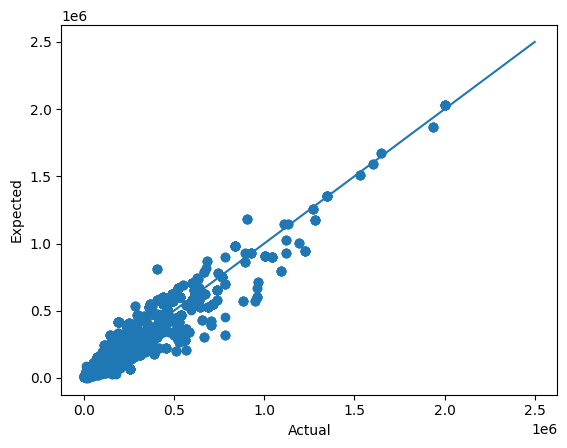

In [140]:
# AvsE all - Training data
fig, ax = plt.subplots()
ax.scatter(train_pred[youtput], train_pred["pred_claims"])
ax.plot([0,3000000],[0,3000000])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Train AvsE all history')               
writer.add_figure('AvsE all Train', fig)


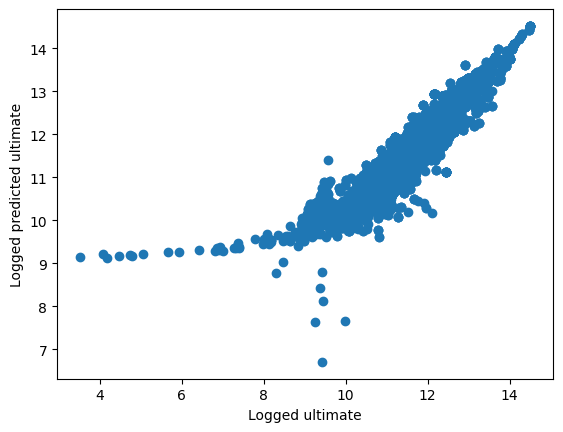

In [141]:
# Logged AvsE all - Training data
fig, ax = plt.subplots()
ax.scatter(train_pred["log_actual"], train_pred["log_pred_claims"])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Logged Train AvsE All History')               
writer.add_figure('AvsE Logged All Train', fig)


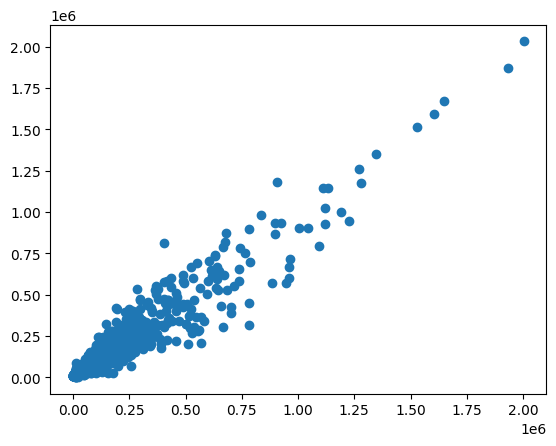

In [142]:
# AvsE Ultimate - Training data (last record per claim)
dat_byclaim = train_pred.groupby("claim_no").last()

fig, ax = plt.subplots()
ax.scatter(dat_byclaim["claim_size"], dat_byclaim["pred_claims"])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Train AvsE Ult only')               
writer.add_figure('AvsE Ult only Train', fig)


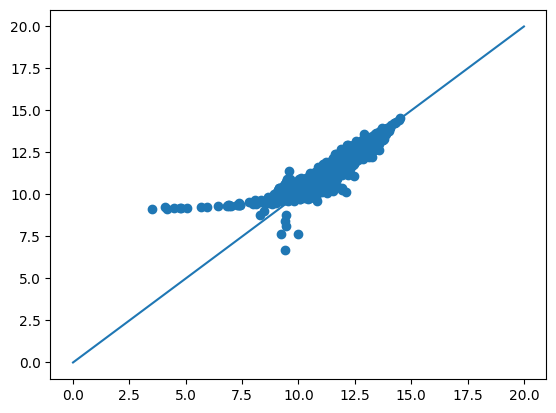

In [143]:
# Logged AvsE Ultimate - Training data
fig, ax = plt.subplots()
ax.scatter(dat_byclaim["log_actual"], dat_byclaim["log_pred_claims"])
ax.plot([0,20],[0,20])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Logged Train AvsE Ult only')               
writer.add_figure('AvsE Ult only Logged Train', fig)


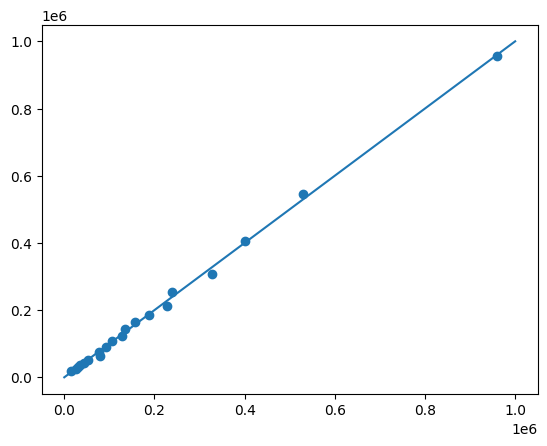

In [144]:
# QQ plot - Training data (20 quantiles)
X_sum = train_pred.groupby("pred_claims_20cile").agg("mean").reset_index()

fig, ax = plt.subplots()
ax.scatter(X_sum.claim_size, X_sum.pred_claims)
ax.plot([0,1000000],[0,1000000])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Train QQ plot 20')               
writer.add_figure('QQ plot Train', fig)

fig, ax = plt.subplots()
ax.scatter(X_sum.log_actual, X_sum.log_pred_claims)
ax.plot([0,20],[0,20])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Logged Train QQ plot 20')               
writer.add_figure('QQ plot Logged Train ', fig)


#### Test Dataset Evaluation


In [145]:
# Generate test set predictions
test = dat.loc[(dat.test_ind_time == 1) & (dat.train_ind == 0) & (dat.train_settled == 0)]

y_pred = model_NN.predict(test)

# One prediction per claim — merge back onto the full transaction-level test data
claim_nos = test["claim_no"].drop_duplicates()
pred_df = pd.DataFrame({"claim_no": claim_nos.values, "pred_claims": y_pred})

if "pred_claims" in test.columns:
    test = test.drop(columns=["pred_claims"])

test_pred = test.merge(pred_df, on="claim_no", how="left")

# Log-transform actuals and predictions for diagnostic plots
test_pred["log_pred_claims"] = np.log1p(test_pred["pred_claims"])
test_pred["log_actual"]      = np.log1p(test_pred[youtput])

# Residuals and reporting delay
test_pred["rpt_delay"] = np.ceil(test_pred.notidel).astype(int)
test_pred["diff"]  = test_pred[youtput] - test_pred["pred_claims"]
test_pred["diffp"] = test_pred["diff"] / test_pred[youtput]

# Quantile bins for QQ plots
test_pred["pred_claims_decile"]      = pd.qcut(test_pred["pred_claims"],     10, labels=False, duplicates='drop')
test_pred["pred_claims_20cile"]      = pd.qcut(test_pred["pred_claims"],     20, labels=False, duplicates='drop')
test_pred["log_pred_claims_decile"]  = pd.qcut(test_pred["log_pred_claims"], 10, labels=False, duplicates='drop')
test_pred["log_pred_claims_20cile"]  = pd.qcut(test_pred["log_pred_claims"], 20, labels=False, duplicates='drop')

save_df_to_excel(test_pred, df_name="pred_test", filename=log_filename, mode='a')
print(f"Test predictions generated: {len(test_pred):,} rows, {test_pred['claim_no'].nunique():,} claims")


Saved DataFrame to 'log_SMD_GRU_outputs_20251009_123127.xlsx' as sheet 'pred_test'


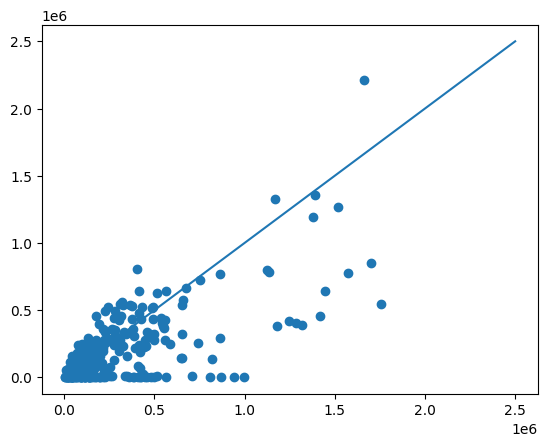

In [146]:
# AvsE All - Test data
fig, ax = plt.subplots()
ax.scatter(test_pred[youtput], test_pred["pred_claims"])
ax.plot([0,3000000],[0,3000000])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Test AvsE all history')               
writer.add_figure('AvsE all Test', fig)

# Logged AvsE All - Test data
fig, ax = plt.subplots()
ax.scatter(test_pred["log_actual"], test_pred["log_pred_claims"])
ax.plot([0,20],[0,20])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Logged Test AvsE All History')               
writer.add_figure('AvsE Logged All Test', fig)

# AvsE Ultimate - Test data (last record per claim)
dat_byclaim = test_pred.groupby("claim_no").last()

fig, ax = plt.subplots()
ax.scatter(dat_byclaim[youtput], dat_byclaim["pred_claims"])
ax.plot([0,3000000],[0,3000000])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Test AvsE Ult only')               
writer.add_figure('AvsE Ult only Test', fig)

# Logged AvsE Ultimate - Test data
fig, ax = plt.subplots()
ax.scatter(dat_byclaim["log_actual"], dat_byclaim["log_pred_claims"])
ax.plot([0,20],[0,20])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Logged Test AvsE Ult only')               
writer.add_figure('AvsE Logged Ult only Test', fig)


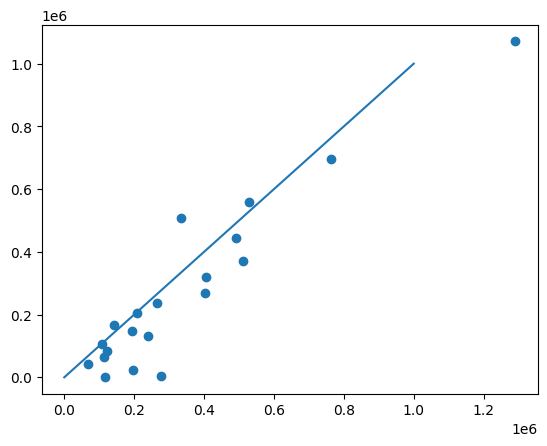

In [147]:
# QQ plot - Test data (20 quantiles)
X_sum = test_pred.groupby("pred_claims_20cile").agg("mean").reset_index()

fig, ax = plt.subplots()
ax.scatter(X_sum.claim_size, X_sum.pred_claims)
ax.plot([0,1000000],[0,1000000])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Test QQ plot 20')               
writer.add_figure('QQ plot Test', fig)

fig, ax = plt.subplots()
ax.scatter(X_sum.log_actual, X_sum.log_pred_claims)
ax.plot([0,20],[0,20])
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Expected', fontsize=15)
ax.set_title('Logged Test QQ plot 20')               
writer.add_figure('QQ plot Logged Test', fig)


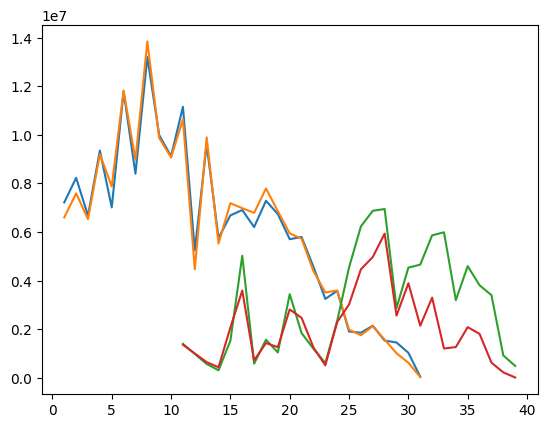

In [148]:
datTrainUlt = train_pred.groupby("claim_no").last()
datTestUlt = test_pred.groupby("claim_no").last()

datTrain_occ = datTrainUlt.groupby("occurrence_period").agg({youtput: "sum", "pred_claims": "sum"})
datTest_occ = datTestUlt.groupby("occurrence_period").agg({youtput: "sum", "pred_claims": "sum"})

# Occurrence period plot (log scale)
fig, ax = plt.subplots()
ax.plot(datTrain_occ.index, datTrain_occ[youtput], linestyle='--', label='Train Actual')
ax.plot(datTrain_occ.index, datTrain_occ.pred_claims, linestyle='--', label='Train Expected')
ax.plot(datTest_occ.index, datTest_occ[youtput], label='Test Actual')
ax.plot(datTest_occ.index, datTest_occ.pred_claims, label='Test Expected')
ax.set_yscale("log") 
ax.set_xlabel('Occurrence period', fontsize=15)
ax.set_ylabel('Total Ultimate claims', fontsize=15)
ax.set_title('by Occurrence Period')     
ax.legend()
writer.add_figure('by Occur Period', fig)


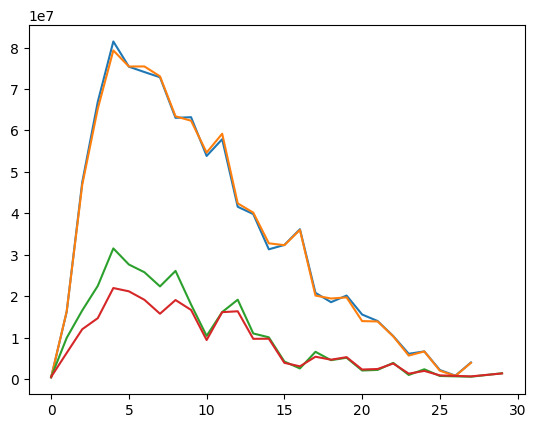

In [149]:
datTrain_dev = train_pred.groupby("development_period").agg({youtput: "sum", "pred_claims": "sum"})
datTest_dev = test_pred.groupby("development_period").agg({youtput: "sum", "pred_claims": "sum"})

# Development period plot
fig, ax = plt.subplots()
ax.plot(datTrain_dev.index, datTrain_dev[youtput], linestyle='--', label='Train Actual')
ax.plot(datTrain_dev.index, datTrain_dev.pred_claims, linestyle='--', label='Train Expected')
ax.plot(datTest_dev.index, datTest_dev[youtput], label='Test Actual')
ax.plot(datTest_dev.index, datTest_dev.pred_claims, label='Test Expected')
ax.set_xlabel('Development period', fontsize=15)
ax.set_ylabel('Total claims', fontsize=15)
ax.set_title('by Development Period')     
ax.legend()
writer.add_figure('by Dev Period', fig)


### Model Internals: Weights, Biases and Gradients

The following cells inspect the learned parameters of the fitted model.
This is useful for debugging and understanding convergence behaviour.


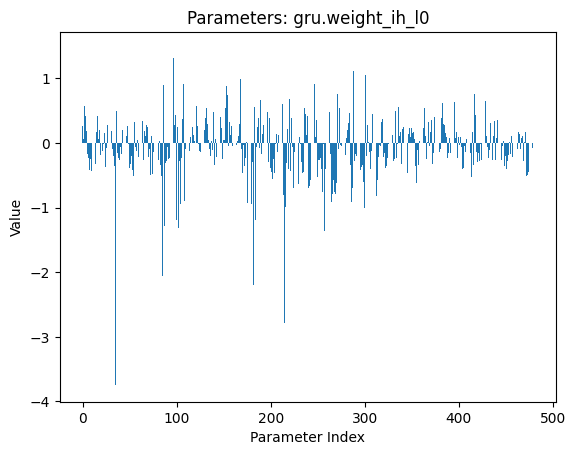

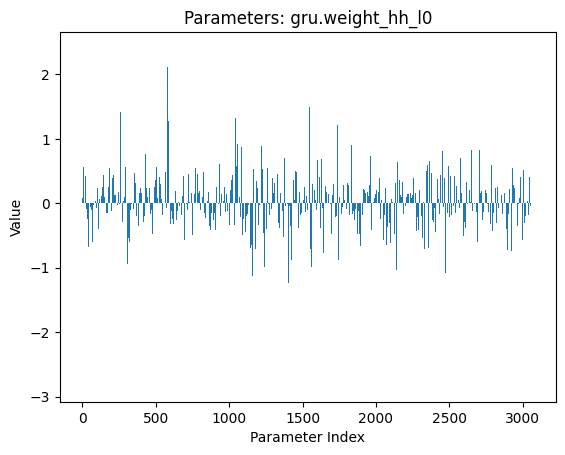

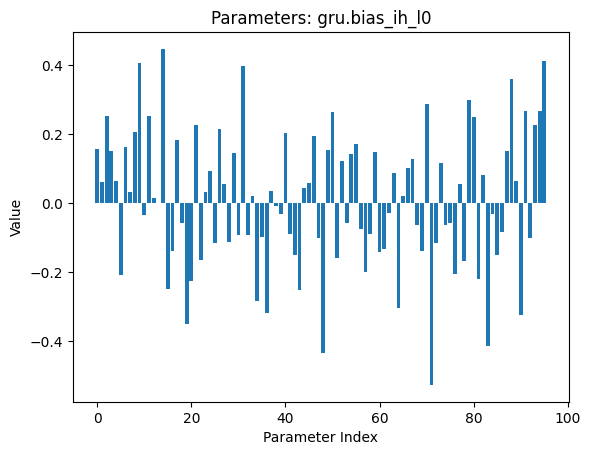

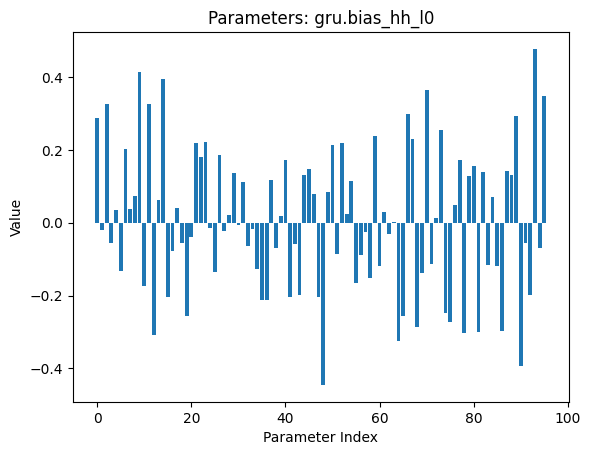

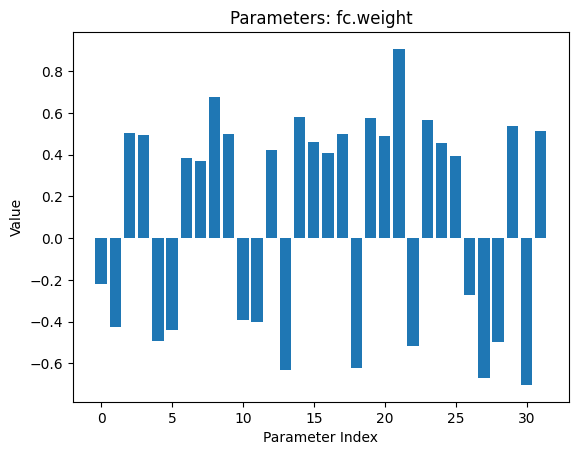

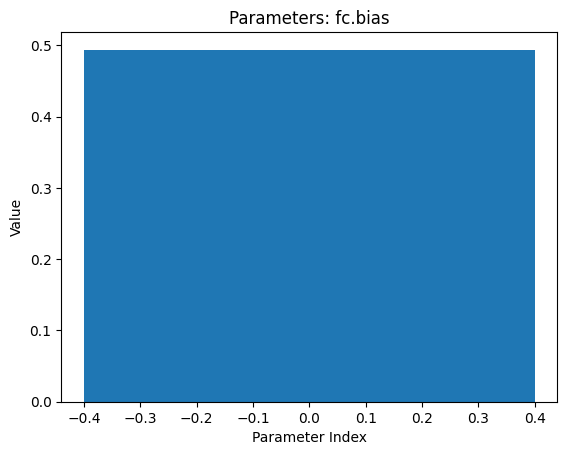

In [150]:
# Extract and display fitted model parameters
fitted_model = model_NN.named_steps['model'].module_

for name, param in fitted_model.named_parameters():
    param_np = param.detach().numpy().flatten()
    fig, ax = plt.subplots()
    ax.bar(range(len(param_np)), param_np)
    ax.set_title(f'Parameters: {name}')
    ax.set_xlabel('Parameter Index')
    ax.set_ylabel('Value')
    plt.show()
    plt.close(fig)


In [151]:
# Print the learned parameter values as DataFrames
keep_params = {
    name: pd.DataFrame(param.detach().numpy().flatten(), columns=[name])
    for name, param in fitted_model.named_parameters()
}

for name, df in keep_params.items():
    print(f"--- {name} ---")
    print(df.to_string())


     gru.weight_ih_l0
0                0.27
1                0.07
2                0.57
3                0.41
4                0.19
..                ...
475              0.11
476              0.45
477              0.13
478              0.19
479             -0.08

[480 rows x 1 columns]
      gru.weight_hh_l0
0                -0.63
1                 0.08
2                 0.28
3                 0.37
4                 0.24
...                ...
3067             -0.12
3068             -0.75
3069              0.32
3070              0.22
3071              0.40

[3072 rows x 1 columns]
    gru.bias_ih_l0
0             0.16
1             0.06
2             0.25
3             0.15
4             0.06
..             ...
91            0.27
92           -0.10
93            0.23
94            0.27
95            0.41

[96 rows x 1 columns]
    gru.bias_hh_l0
0             0.29
1            -0.02
2             0.33
3            -0.06
4             0.04
..             ...
91           -0.06
92      

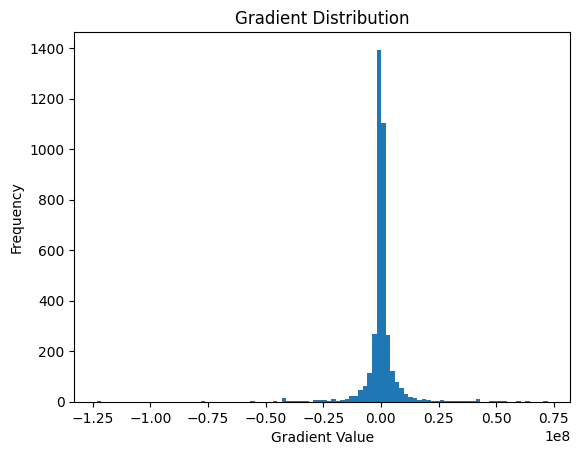

In [152]:
gradients = []

for param in fitted_model.parameters():
    if param.grad is not None:
        gradients.append(param.grad.view(-1).cpu().numpy())

plt.hist(np.concatenate(gradients), bins=100)
plt.title("Gradient Distribution")
plt.xlabel("Gradient Value")
plt.ylabel("Frequency")
plt.show()